In [9]:
import pandas as pd
df = pd.read_excel('/content/listings.airbnb.xlsx')

In [10]:
print(df.shape)
print(df.columns.tolist())

(92799, 19)
['id', 'name', 'host_id', 'host_profile_id', 'host_name', 'neighbourhood_group', 'neighbourhood', 'latitude', 'longitude', 'room_type', 'price', 'minimum_nights', 'number_of_reviews', 'last_review', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365', 'number_of_reviews_ltm', 'license']


In [11]:
df = df.dropna(subset=['price'])

In [16]:
df = df.drop(columns=['neighbourhood_group', 'license'])

In [17]:
df.to_csv('listings_cleaned.csv', index=False)

In [12]:
price_cap = df['price'].quantile(0.99)
df = df[df['price'] <= price_cap]

In [13]:
df['last_review'] = pd.to_datetime(df['last_review'])

In [18]:
print(df.shape)
print(df.isnull().sum())
print(df['price'].describe())

(61774, 17)
id                                    0
name                                  1
host_id                             157
host_profile_id                     233
host_name                           223
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        3
number_of_reviews                     0
last_review                       13290
reviews_per_month                 13290
calculated_host_listings_count      157
availability_365                      0
number_of_reviews_ltm                 0
dtype: int64
count    61774.000000
mean       233.049649
std        195.155941
min          2.000000
25%         99.000000
50%        179.000000
75%        296.000000
max       1373.000000
Name: price, dtype: float64


In [19]:
df.to_csv('listings_cleaned.csv', index=False)

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Airbnb brand palette
RAUSCH = '#FF5A5F'
RADICAL_RED = '#FF385C'
DEEP_ACCENT = '#E31C5F'
WHITE = '#FFFFFF'
BLACK = '#000000'

plt.rcParams['figure.facecolor'] = WHITE
plt.rcParams['axes.facecolor'] = WHITE
plt.rcParams['text.color'] = BLACK
plt.rcParams['axes.labelcolor'] = BLACK
plt.rcParams['xtick.color'] = BLACK
plt.rcParams['ytick.color'] = BLACK

**Chart 1: Average price by borough (top 15)**

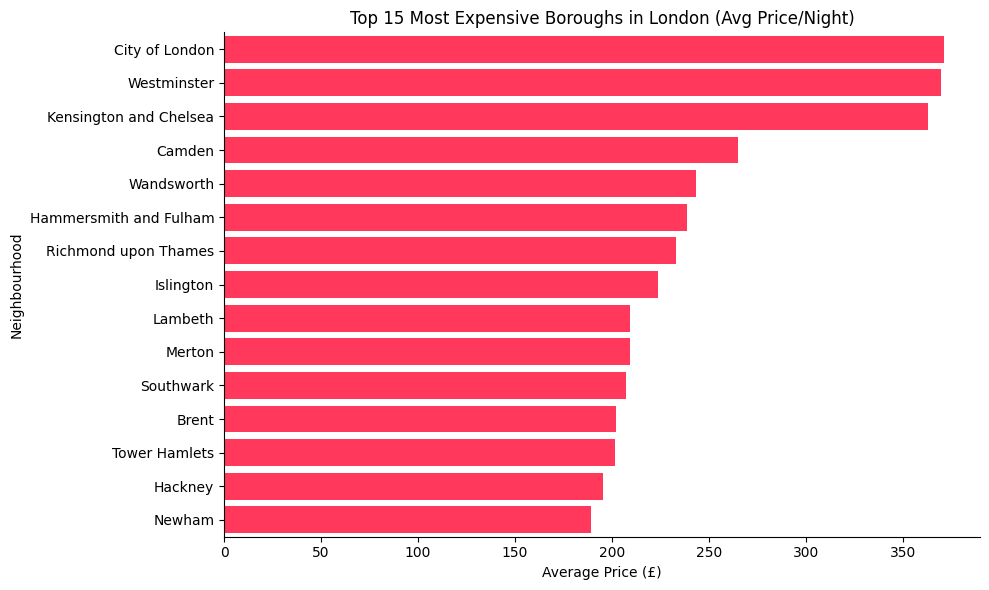

In [31]:
avg_price = df.groupby('neighbourhood')['price'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=avg_price.values, y=avg_price.index, color='#FF385C', saturation=1)
plt.title('Top 15 Most Expensive Boroughs in London (Avg Price/Night)', color='black')
plt.xlabel('Average Price (£)')
plt.ylabel('Neighbourhood')
sns.despine()
plt.tight_layout()
plt.savefig('chart1_price_by_borough.png', dpi=300, facecolor='white')
plt.show()

**Chart 2: Room type distribution**

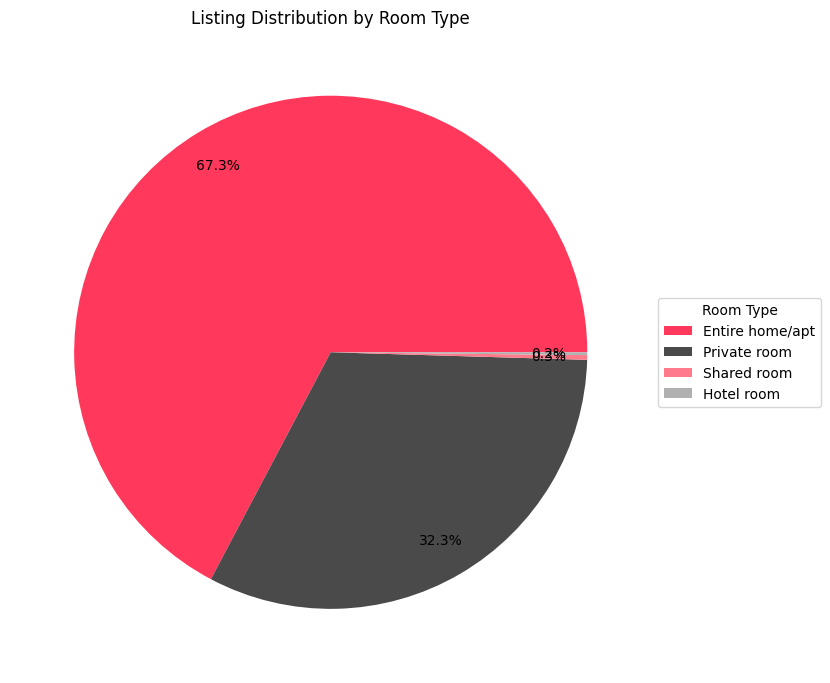

In [26]:
plt.figure(figsize=(8,7))
wedges, texts, autotexts = plt.pie(
    room_counts,
    autopct='%1.1f%%',
    colors=colors,
    textprops={'color': BLACK},
    pctdistance=0.85
)
plt.legend(wedges, room_counts.index, title="Room Type", loc="center left", bbox_to_anchor=(1, 0.5))
plt.title('Listing Distribution by Room Type', color=BLACK)
plt.tight_layout()
plt.savefig('chart2_room_type.png', dpi=300, facecolor=WHITE)
plt.show()

**Chart 3: Price distribution (histogram) — shows the overall pricing landscape**

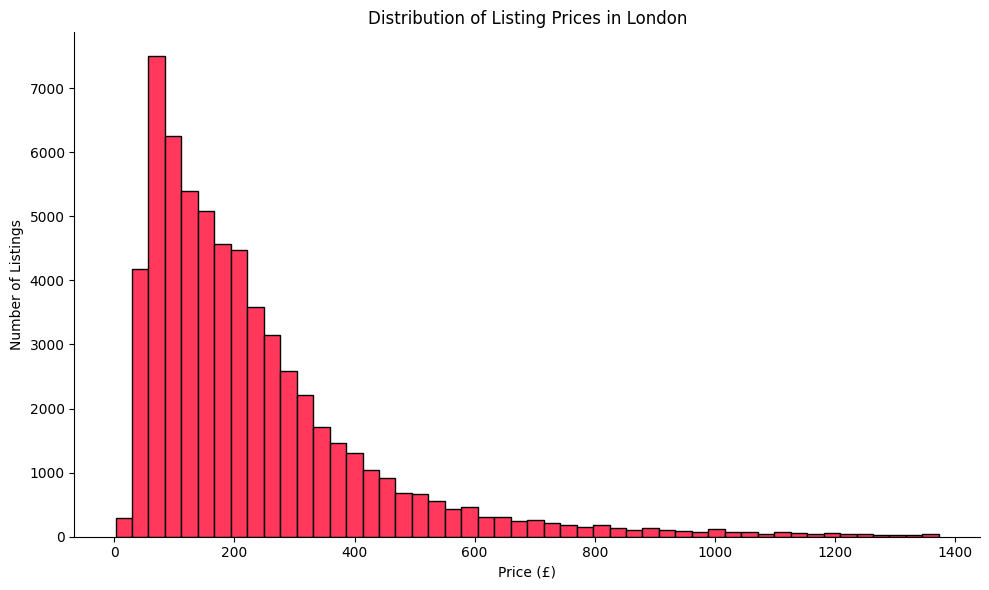

In [33]:
plt.figure(figsize=(10,6))
sns.histplot(df['price'], bins=50, color='#FF385C', alpha=1)
plt.title('Distribution of Listing Prices in London', color='black')
plt.xlabel('Price (£)')
plt.ylabel('Number of Listings')
sns.despine()
plt.tight_layout()
plt.savefig('chart3_price_distribution.png', dpi=300, facecolor='white')
plt.show()

**Chart 4: Number of listings per borough (top 15) — shows supply/popularity, different from Chart 1's pricing angle**

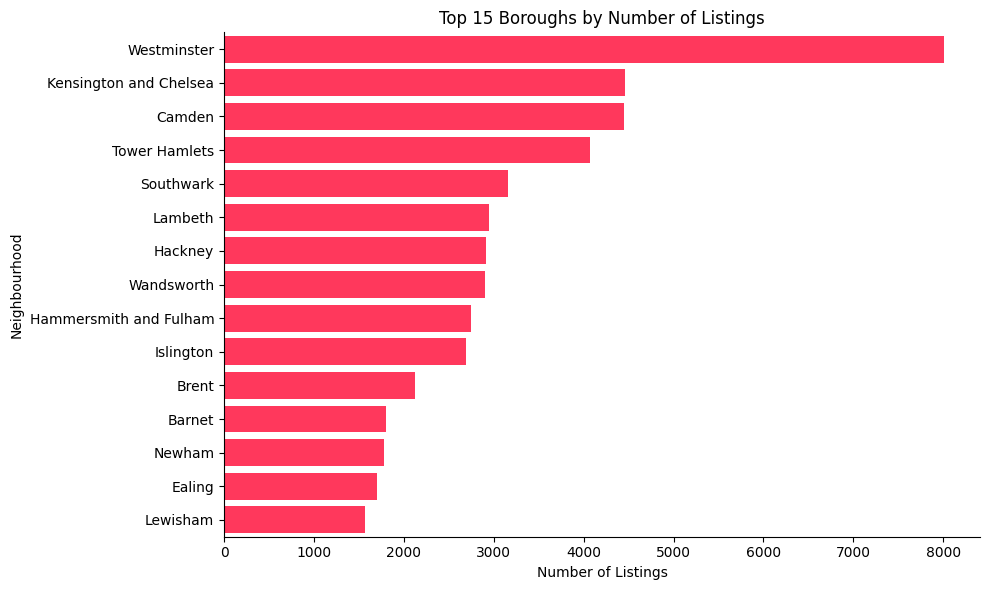

In [38]:
listing_counts = df['neighbourhood'].value_counts().head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=listing_counts.values, y=listing_counts.index, color='#FF385C', saturation=1)
plt.title('Top 15 Boroughs by Number of Listings', color='black')
plt.xlabel('Number of Listings')
plt.ylabel('Neighbourhood')
sns.despine()
plt.tight_layout()
plt.savefig('chart4_listings_per_borough.png', dpi=300, facecolor='white')
plt.show()

**Chart 5: Price by room type (boxplot)**

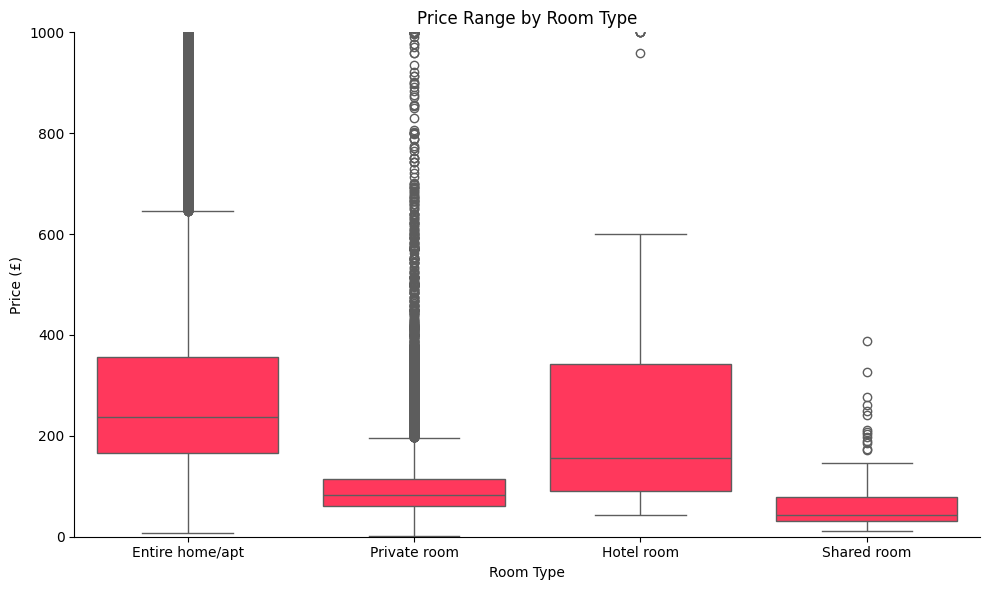

In [34]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='room_type', y='price', color='#FF385C', saturation=1)
plt.title('Price Range by Room Type', color='black')
plt.xlabel('Room Type')
plt.ylabel('Price (£)')
plt.ylim(0, 1000)  # cropped for readability, since we capped outliers earlier
sns.despine()
plt.tight_layout()
plt.savefig('chart5_price_by_roomtype.png', dpi=300, facecolor='white')
plt.show()

**Chart 6: Availability vs price (scatter)**

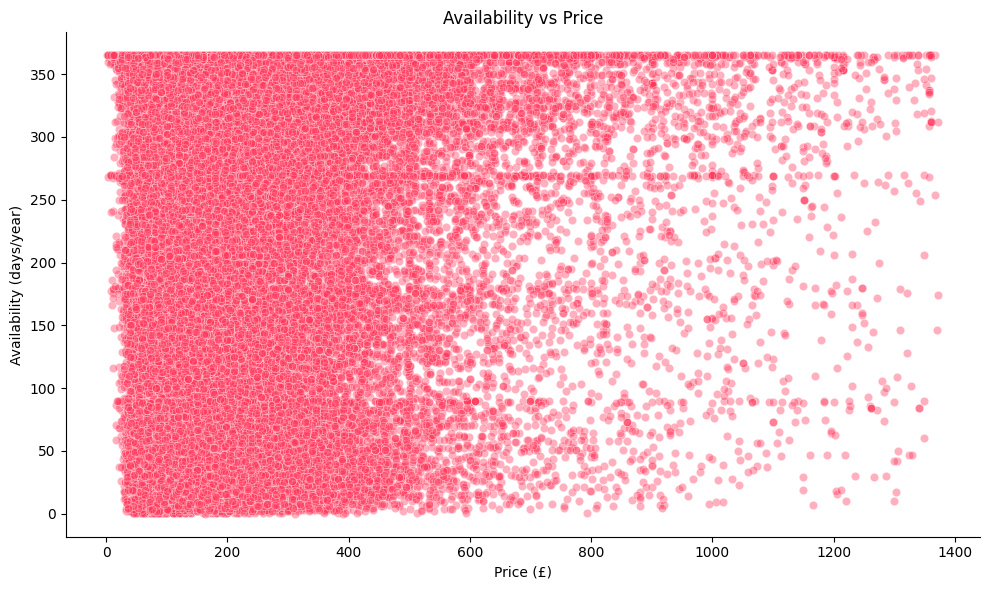

In [35]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='price', y='availability_365', color='#FF385C', alpha=0.4)
plt.title('Availability vs Price', color='black')
plt.xlabel('Price (£)')
plt.ylabel('Availability (days/year)')
sns.despine()
plt.tight_layout()
plt.savefig('chart6_availability_vs_price.png', dpi=300, facecolor='white')
plt.show()

**Chart 7: Correlation between reviews and price**

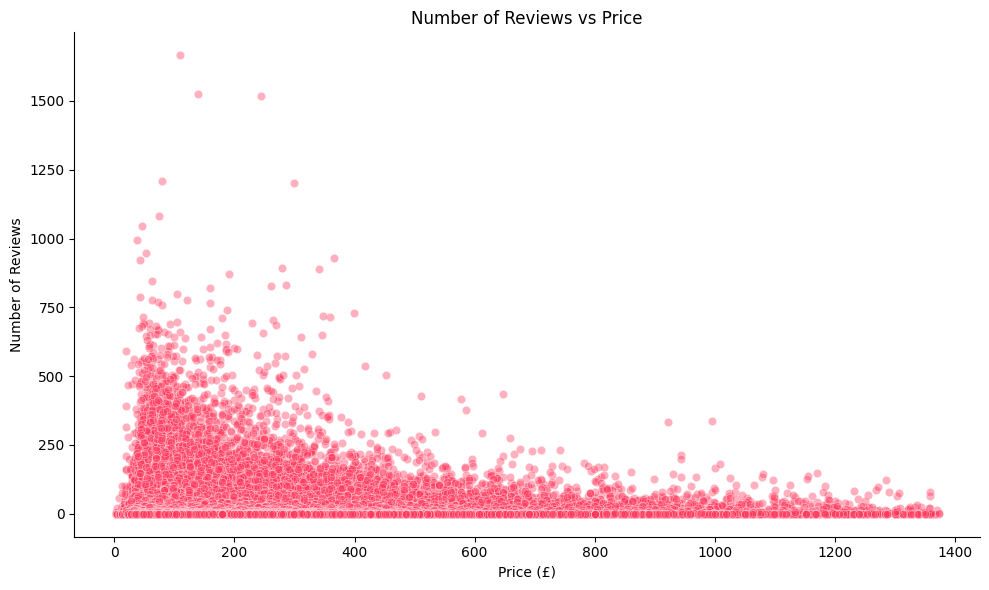

In [36]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='price', y='number_of_reviews', color='#FF385C', alpha=0.4)
plt.title('Number of Reviews vs Price', color='black')
plt.xlabel('Price (£)')
plt.ylabel('Number of Reviews')
sns.despine()
plt.tight_layout()
plt.savefig('chart7_reviews_vs_price.png', dpi=300, facecolor='white')
plt.show()

**Chart 8: Top hosts by listing count**

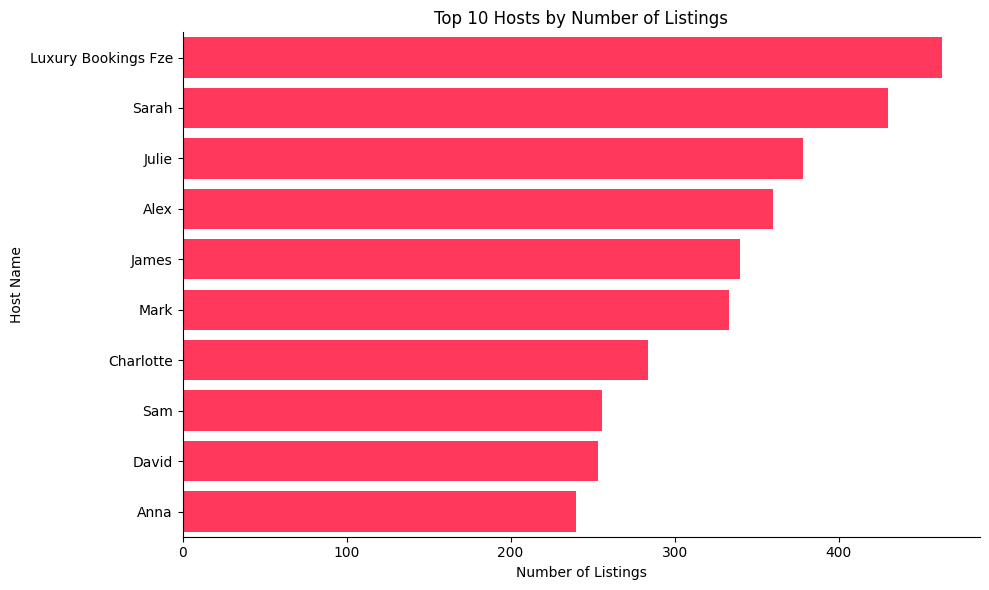

In [37]:
top_hosts = df.groupby('host_name')['id'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_hosts.values, y=top_hosts.index, color='#FF385C', saturation=1)
plt.title('Top 10 Hosts by Number of Listings', color='black')
plt.xlabel('Number of Listings')
plt.ylabel('Host Name')
sns.despine()
plt.tight_layout()
plt.savefig('chart8_top_hosts.png', dpi=300, facecolor='white')
plt.show()